# ACCESS-OM3 depth-latitude temperature and temperature difference from WOA23

Related issue: https://github.com/ACCESS-Community-Hub/access-om3-25km-paper-1/issues/11

In [1]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json"

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [2]:
if not papermill: 
    import nci_ipynb, os  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
from mkfigs import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)

In [3]:
IAF = esm_file.find('iaf') > 0
IAF

True

In [4]:
import os
import numpy as np
import xarray as xr
import cftime
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg
import gsw
import intake
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl
from distributed import Client
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cft
from shapely import geometry
from textwrap import wrap
from tqdm.notebook import tqdm
xr.set_options(keep_attrs=True);  # cf_xarray works best when xarray keeps attributes by default

In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [6]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40791,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34559,Total threads: 1
Dashboard: /proxy/42285/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:37409,


## Define regions

Global maxy changed from 90 to 65 to omit tripolar region


Text(0.5, 1.0, 'Regions (BUG: incorrect shapes north of 65°N)')

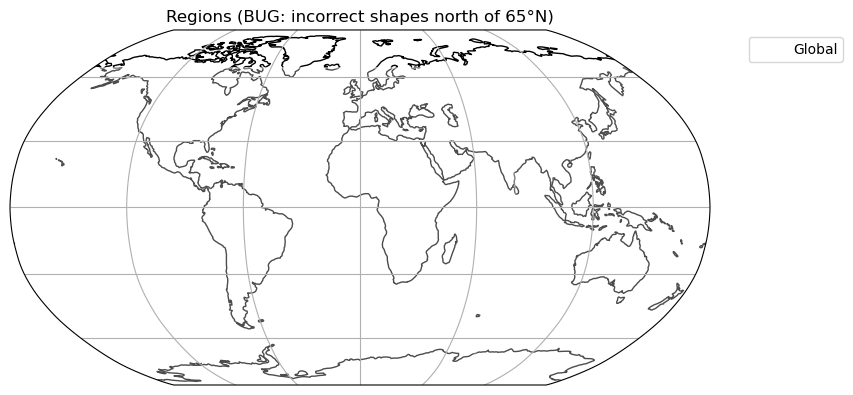

In [7]:
regions = { # [minx, maxx, miny, maxy], using model longitude range (-280 to 80)
    "Global": [-280, 80, -90, 90],
    # "Arctic": [-280, 80, 65, 90],
    # "Southern Ocean": [-280, 80, -82, -63],
    # "ACC": [-280, 80, -63, -45],
    # "Southern Pacific": [-210, -70, -45, -20],
    # "Tropical Pacific": [-240, -100, -20, 20],
    # "North Pacific": [-240, -100, 20, 65],
    # "South Atlantic": [-60, 20, -45, -20],
    # "Tropical Atlantic": [-70, 20, -20, 20],
    # "North Atlantic": [-100, 0, 20, 65],
    # "Indian": [30, 120, -45, 20],
    # "Aegean Sea": [18, 27.5, 34, 44],
    # "Black Sea": [27.5, 43, 40.5, 48],
    # "Baltic Sea": [13, 30, 53, 58],
    # "Mediterranean Sea": [0, 35, 31, 41],
    # "Red Sea": [33, 44, 12, 29],
    # "Persian Gulf": [47, 56, 24, 31],
    # "White Sea": [31, 41, 63, 68],
}
regions = {k: dict(zip(["minx", "maxx", "miny", "maxy"], v)) for k, v in regions.items()}  # convert to dicts

for r, d in regions.items():
    for k, x in d.items():
        if k in ["minx", "maxx"] and x != max(-280, min(x, 80)):
            raise ValueError(f"{r} {k} = {x} is outside the range -280 to 80")
        if k in ["miny", "maxy"] and x > 65:
            print(f"{r} {k} changed from {x} to 65 to omit tripolar region")
            d[k] = 65
            

fig = plt.figure(figsize=(10, 4))

colors = mpl.color_sequences['tab20']
try:  # set Global color to white 
    colors[list(regions.keys()).index("Global")] = (1, 1, 1)
except ValueError:
    pass

ax = plt.axes(position=[0.05,0.05,0.7,0.9], projection=ccrs.Robinson())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=False)

legend_elements = []
for i, (region, limits) in enumerate(regions.items()):
    ax.add_geometries([geometry.box(**limits)], crs=ccrs.PlateCarree(), color=colors[i], alpha=0.3)
    legend_elements.append(Patch(color=colors[i], alpha=0.3, label=region))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.2, 1.00))
plt.title("Regions (BUG: incorrect shapes north of 65°N)")

## Load data from WOA

NB: we're taking a mean of the monthly means. This reduces seasonal bias relative to the annual mean WOA (I think!), but will also involve more interpolated values.

The alternative would be to use the WOA annual mean `/g/data/ik11/observations/woa23/woa23_decav_[ts]00_04.nc` but this needs to be converted to the appropriate temperature and salinity, and regridded to model grid.


In [8]:
# fragile! depends on model run!
obs_file_pattern = "/g/data/ik11/inputs/access-om3/woa23/025/2025.10.24/woa23_ts_*"

# Load observational / reference SST (e.g. WOA23) in a model-agnostic way
ds_obs = xr.open_mfdataset(
    obs_file_pattern,
    chunks={"time": -1},
).cf.mean("time")

woavars = { k: ds_obs[k] for k in ["temp", "salt"] }

In [9]:
%%time
# calculate zonal mean for each region
woavars_mean = {
    region:
    {
        vname: da.cf.sel( latitude=slice(b['miny'], b['maxy']))\
                 .cf.sel(longitude=slice(b['minx'], b['maxx']))\
                 .cf.mean('longitude').load()
        for vname, da in tqdm(woavars.items(), desc=f'   {region} variables')
    }
    for region, b in tqdm(regions.items(), desc='regions')
}
woavars_mean

regions:   0%|          | 0/1 [00:00<?, ?it/s]

   Global variables:   0%|          | 0/2 [00:00<?, ?it/s]

CPU times: user 11.7 s, sys: 5.65 s, total: 17.3 s
Wall time: 26.4 s


{'Global': {'temp': <xarray.DataArray 'temp' (depth: 75, lat: 912)> Size: 547kB
  array([[-1.41657562, -1.41696925, -1.41736293, ...,  2.88408713,
           2.81241465,  2.74889647],
         [-1.42911698, -1.42946652, -1.42981611, ...,  2.79461266,
           2.72298154,  2.65983035],
         [-1.44297652, -1.44327734, -1.44357821, ...,  2.69573383,
           2.62414842,  2.56140279],
         ...,
         [-2.00222664, -2.00213021, -2.00203376, ..., -1.10633219,
          -1.13140287, -1.16729923],
         [-2.00222664, -2.00213021, -2.00203376, ..., -1.10675505,
          -1.13174071, -1.16757505],
         [-2.00222664, -2.00213021, -2.00203376, ..., -1.10675505,
          -1.13174071, -1.16757505]], shape=(75, 912))
  Coordinates:
    * depth    (depth) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
    * lat      (lat) float64 7kB -81.58 -81.52 -81.45 -81.39 ... 64.76 64.87 64.97
  Attributes:
      units:          degrees celsius
      standard_name:  sea_water_cons

### alternative approach for WOA data - not used

Would need to interpolate WOA data onto model grid

## Load data from ACCESS-OM3

In [10]:
catalogs = [
                esm_file,
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm1-d968c801/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm2-5dc49da6/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm3-da330542/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm4-9fd08880/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm5-9b5dbfa9/datastore.json',
                # '/g/data/ol01/access-om3-output/access-om3-025/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json',
            ]
catalogs

['/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json']

In [11]:
om3datastores = { os.path.normpath(c).split(os.sep)[-2]:
               intake.open_esm_datastore(c,
                                         columns_with_iterables=[
                                            "variable",
                                            "variable_long_name",
                                            "variable_standard_name",
                                            "variable_cell_methods",
                                            "variable_units"]
                                        )
              for c in catalogs }
om3datastores

{'MC_25km_jra_iaf+wombatlite-test3v2-00532b88': <datastore catalog with 24 dataset(s) from 32927 asset(s)>}

In [12]:
om3varnames = [ 'thetao', 'so' ]

om3vars = {
    vname: {expt: ds.search(variable=vname).to_dask(
                xarray_open_kwargs = dict(
                    chunks={"xh": -1, "yh": -1, "z_l": -1},  # remove "yh": -1 for resolution finer than 25km 
                    decode_timedelta=True
                )
            )[vname]
            for expt, ds in om3datastores.items()
          }
    for vname in om3varnames
    }

# omit latitudes with grid bug in this run https://github.com/ACCESS-NRI/ocean_model_grid_generator/issues/7
for vname, d in om3vars.items():
    try:
        d['25km-iaf-test-for-AK-expt-7df5ef4c'] = d['25km-iaf-test-for-AK-expt-7df5ef4c'].isel(yh=slice(10, None))
    except ValueError:
        d['25km-iaf-test-for-AK-expt-7df5ef4c'] = d['25km-iaf-test-for-AK-expt-7df5ef4c'].isel(yq=slice(10, None))
    except KeyError:
        pass

if IAF:
    for vname, d in om3vars.items():
        for expt in d:
            try:
                d[expt] = d[expt].convert_calendar("proleptic_gregorian", use_cftime=True)
            except KeyError:
                pass

## Load data from ACCESS-OM2
use control - see https://forum.access-hive.org.au/t/access-om2-control-experiments/258#p-747-ryf-7

In [13]:
if IAF:
    om2exptname = '025deg_jra55_iaf_omip2_cycle1'
else:
    om2exptname = '025deg_jra55_ryf9091_gadi'  # monthly temp only for 1900-1903, and 2300-, with annual data in the gap
om2datastores = {om2exptname: intake.cat.access_nri[om2exptname]}

In [14]:
om2varnames = [ 'temp', 'salt' ]

om2vars = {
    vname: {expt: ds.search(variable=vname, frequency="1mon").to_dask(
                xarray_open_kwargs = dict(
                    chunks={"xt_ocean": -1, "yt_ocean": -1, "st_ocean" : -1},  # remove "yt_ocean": -1 for resolution finer than 25km
                    decode_timedelta=True
                )
            )[vname]
            for expt, ds in om2datastores.items()
          }
    for vname in om2varnames
    }

if IAF:
    for vname, d in om2vars.items():
        for expt in d:
            try:
                d[expt] = d[expt].convert_calendar("proleptic_gregorian", use_cftime=True)
            except KeyError:
                pass

for expt, da in om2vars['temp'].items():
    try:
        om2vars['temp'][expt] = om2vars['temp'][expt] - 273.15  # convert to degC
        om2vars['temp'][expt].attrs['units'] = 'degC'
    except KeyError:
        pass

## Set time range

In [15]:
lasttime = []
for vname, d in om3vars.items():
    for expt, da in d.items():
        lasttime.append(da.time.values[-1])

if IAF:
    # datestop = cftime.DatetimeProlepticGregorian(2018, 12, 31, 12, 0, 0, 0, has_year_zero=True)  # to match OM2 IAF run
    datestop = min(lasttime) # earliest final date in data
    datelist = list(cftime.to_tuple(datestop))
    datelist[0] -= 10  # last 10 years
    datestart = cftime.datetime(*datelist, calendar=datestop.calendar)
    timerange = slice(datestart, datestop)
else:
    timerange = slice(cftime.DatetimeNoLeap(1932, 1, 1, 0, 0, 0, 0),
                      cftime.DatetimeNoLeap(1952, 1, 1, 0, 0, 0, 0))

# timerange = slice(None, None)

timerange

slice(cftime.datetime(2013, 12, 16, 12, 0, 0, 0, calendar='proleptic_gregorian', has_year_zero=True), cftime.DatetimeProlepticGregorian(2023, 12, 16, 12, 0, 0, 0, has_year_zero=True), None)

## Calculate zonal mean for each region - SLOW!

In [16]:
%%time
om3vars_mean = {
    region:
    {
        vname: {
                expt: da.sel(yh=slice(b['miny'], b['maxy']))\
                        .sel(xh=slice(b['minx'], b['maxx']))\
                        .sel(time=timerange)\
                        .mean('xh').mean('time').load()
                for expt, da in tqdm(vdatadict.items(), desc=f'      {vname} experiments', )
              }
        for vname, vdatadict in tqdm(om3vars.items(), desc=f'   {region} variables')
    }
    for region, b in tqdm(regions.items(), desc='regions')
}

regions:   0%|          | 0/1 [00:00<?, ?it/s]

   Global variables:   0%|          | 0/2 [00:00<?, ?it/s]

      thetao experiments:   0%|          | 0/1 [00:00<?, ?it/s]

      so experiments:   0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 18.4 s, sys: 8.97 s, total: 27.3 s
Wall time: 48.2 s


In [17]:
%%time
om2vars_mean = {
    region:
    {
        vname: {
                expt: da.sel(yt_ocean=slice(b['miny'], b['maxy']))\
                        .sel(xt_ocean=slice(b['minx'], b['maxx']))\
                        .sel(time=timerange)\
                        .mean('xt_ocean').mean('time').load()
                for expt, da in tqdm(vdatadict.items(), desc=f'      {vname} experiments', )
              }
        for vname, vdatadict in tqdm(om2vars.items(), desc=f'   {region} variables')
    }
    for region, b in tqdm(regions.items(), desc='regions')
}

regions:   0%|          | 0/1 [00:00<?, ?it/s]

   Global variables:   0%|          | 0/2 [00:00<?, ?it/s]

      temp experiments:   0%|          | 0/1 [00:00<?, ?it/s]

      salt experiments:   0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 6.17 s, sys: 3.05 s, total: 9.22 s
Wall time: 16.6 s


## Regridders
See https://github.com/aekiss/ice_analysis/blob/main/ice_maps.ipynb

## Plot zonal means for each region

In [18]:
def doplots(om3variable = "thetao",
            om2variable = "temp",
            vmin = None, vmax = None,
            cmap = cmocean.cm.thermal):
    for region, d in om3vars_mean.items():
        npanels = len(d[om3variable]) + len(om2vars_mean[region][om2variable])
        nrows = (npanels+1)//2
        fig, axs = plt.subplots(nrows, 2,
                                figsize=(9, 3*nrows),
                                sharex=True, sharey=True)
        fig.suptitle(f'{region} zonal mean, {timerange.start.strftime("%Y-%m-%d")} - {timerange.stop.strftime("%Y-%m-%d")}')

        if vmin == None: # calculate min over all panels (different for each region)
            vmin = 1e20
            for i, (expt, da) in enumerate(d[om3variable].items(), start=1):
                vmin = min(vmin, da.min().data)
            for i2, (expt, da) in enumerate(om2vars_mean[region][om2variable].items(), start=i+1):
                vmin = min(vmin, da.min().data)

        if vmax == None: # calculate max over all panels (different for each region)
            vmax = -1e20
            for i, (expt, da) in enumerate(d[om3variable].items(), start=1):
                vmax = max(vmax, da.max().data)
            for i2, (expt, da) in enumerate(om2vars_mean[region][om2variable].items(), start=i+1):
                vmax = max(vmax, da.max().data)

        # ACCESS-OM3
        for i, (expt, da) in enumerate(d[om3variable].items(), start=1):
            # print(da)
            plt.subplot(nrows, 2, i).set_facecolor('gray')  # gray land points
            p = da.plot.contourf(
                levels=101, vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False,
            )
            da.plot.contour(
                levels=25, vmin=vmin, vmax=vmax, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
            )
            plt.gca().set_ylim([0, None])
            plt.gca().invert_yaxis()
            plt.title(f"ACCESS-OM3 {expt} {om3variable}", fontsize=8)
            plt.xlabel('')
            plt.ylabel('Depth [m]')
            label = f"ACCESS-OM3: {da.attrs['long_name']} ({om3variable}) [{da.attrs['units']}]"

        # ACCESS-OM2
        for i2, (expt, da) in enumerate(om2vars_mean[region][om2variable].items(), start=i+1):
            plt.subplot(nrows, 2, i2).set_facecolor('gray')  # gray land points
            da.plot.contourf(
                levels=101, vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False,
            )
            da.plot.contour(
                levels=25, vmin=vmin, vmax=vmax, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
            )
            plt.gca().set_ylim([0, None])
            plt.gca().invert_yaxis()
            plt.title(f"ACCESS-OM2 {expt} {om2variable}", fontsize=8)
            plt.xlabel('')
            plt.ylabel('Depth [m]')
            label += f"\nACCESS-OM2: {da.attrs['long_name']} ({om2variable}) [{da.attrs['units']}]"
    
        for ax in fig.get_axes():
            ax.label_outer()
        plt.tight_layout()
        fig.colorbar(p, ax=axs, orientation='horizontal',
                     fraction=.1, shrink=0.7, aspect=40,
                     label=label)

        mkmd.savefig("Zonal mean temperature and salinity transects", "ACCESS-OM3 and ACCESS-OM2 zonal mean "+om3variable)

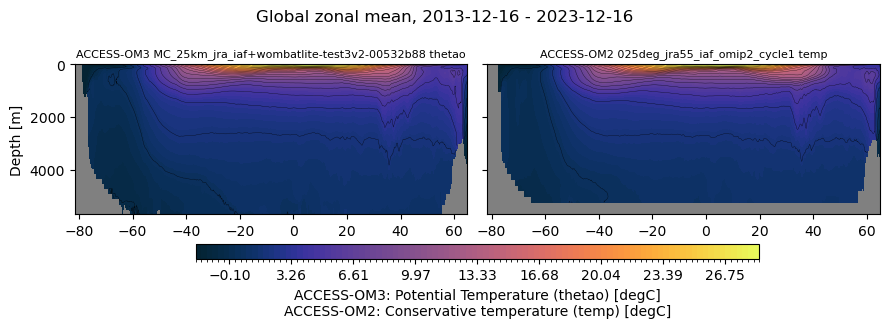

In [19]:
doplots(om3variable="thetao",
        om2variable="temp")

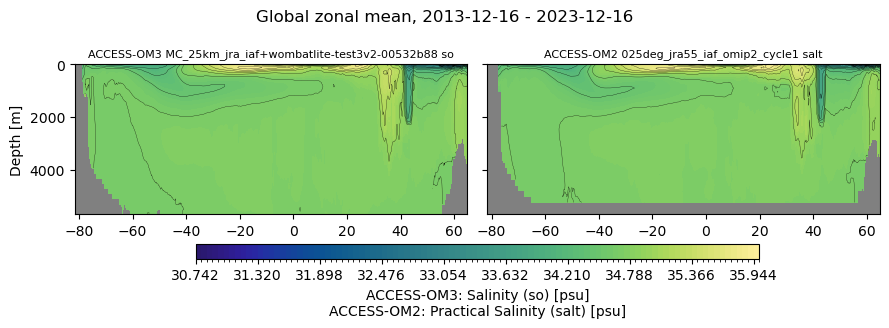

In [20]:
doplots(om3variable="so",
        om2variable="salt",
        cmap=cmocean.cm.haline)